<a href="https://colab.research.google.com/github/MaciejRR/NBA-Regular-Season-Analysis-2025-26/blob/main/NBA_Regular_Season_Analysis_(2025_26).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Regular Season Analysis (2025-26)

This project explores player performance in the 2025-26 NBA regular season using publicly available data from Basketball Reference.

The goal is to clean the dataset, prepare it for analysis, and identify interesting patterns in scoring, efficiency, and overall player performance.

## Loading the data

The per-game player statistics table was loaded directly from Basketball Reference using `pandas.read_html()`.

In [1]:
import pandas as pd

url = "https://www.basketball-reference.com/leagues/NBA_2026_per_game.html"
df = pd.read_html(url)[0]

df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,35.8,10.8,22.8,...,0.6,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,AS
1,2.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,33.2,10.8,19.4,...,0.6,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,AS
2,3.0,Anthony Edwards,24.0,MIN,SG,61.0,60.0,35.0,9.9,20.2,...,0.6,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,AS
3,4.0,Jaylen Brown,29.0,BOS,SF,71.0,71.0,34.4,10.4,21.7,...,1.1,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,AS
4,5.0,Tyrese Maxey,25.0,PHI,PG,70.0,70.0,38.0,9.9,21.4,...,0.3,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,AS


In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Rk      733 non-null    float64
 1   Player  734 non-null    object 
 2   Age     733 non-null    float64
 3   Team    733 non-null    object 
 4   Pos     732 non-null    object 
 5   G       733 non-null    float64
 6   GS      733 non-null    float64
 7   MP      733 non-null    float64
 8   FG      733 non-null    float64
 9   FGA     733 non-null    float64
 10  FG%     731 non-null    float64
 11  3P      733 non-null    float64
 12  3PA     733 non-null    float64
 13  3P%     683 non-null    float64
 14  2P      733 non-null    float64
 15  2PA     733 non-null    float64
 16  2P%     727 non-null    float64
 17  eFG%    731 non-null    float64
 18  FT      733 non-null    float64
 19  FTA     733 non-null    float64
 20  FT%     703 non-null    float64
 21  ORB     733 non-null    float64
 22  DR

## Initial cleaning

One non-player row was removed from the dataset.  
I also identified players who appeared multiple times due to mid-season team changes.

To handle this properly, I created:
- `df_raw` — the original dataset with all player-team rows,
- `df_players` — a cleaned dataset with one row per player.

For traded players, I kept the combined row (for example `2TM`) and removed the individual team rows.

In [6]:
df[df.isna().any(axis=1)]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
9,10.0,Joel Embiid,31.0,PHI,C,38.0,38.0,31.6,9.0,18.3,...,2.0,5.7,7.7,3.9,0.6,1.2,2.9,2.2,26.9,NaN
10,11.0,Lauri Markkanen,28.0,UTA,PF,42.0,42.0,34.4,9.1,19.2,...,2.0,4.9,6.9,2.1,1.0,0.5,1.5,1.8,26.7,NaN
18,19.0,Michael Porter Jr.,27.0,BRK,SF,52.0,52.0,32.5,8.5,18.4,...,1.3,5.7,7.1,3.0,1.1,0.3,2.3,2.2,24.2,NaN
21,22.0,James Harden,36.0,2TM,PG,70.0,70.0,34.8,7.0,16.0,...,0.6,4.2,4.8,8.0,1.1,0.4,3.5,2.0,23.6,NaN
22,22.0,James Harden,36.0,LAC,PG,44.0,44.0,35.4,7.3,17.5,...,0.6,4.2,4.8,8.1,1.3,0.4,3.7,1.9,25.4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,579.0,Darius Brown II,26.0,CLE,SG,1.0,0.0,3.0,0.0,1.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
730,580.0,Noa Essengue,19.0,CHI,PF,2.0,0.0,3.0,0.0,1.5,...,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,NaN
731,581.0,Tosan Evbuomwan,24.0,NYK,SF,5.0,0.0,1.6,0.0,0.2,...,0.2,0.2,0.4,0.0,0.0,0.0,0.0,0.2,0.0,NaN
732,582.0,Chucky Hepburn,22.0,TOR,PG,2.0,0.0,6.5,0.0,3.0,...,0.0,0.5,0.5,1.0,0.5,0.0,0.5,1.0,0.0,NaN


In [18]:
# Remove summary/non-player rows with missing rank values
df = df.dropna(subset=["Rk"]).copy()

In [10]:
df[df["Player"] == "James Harden"]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
21,22.0,James Harden,36.0,2TM,PG,70.0,70.0,34.8,7.0,16.0,...,0.6,4.2,4.8,8.0,1.1,0.4,3.5,2.0,23.6,NaN
22,22.0,James Harden,36.0,LAC,PG,44.0,44.0,35.4,7.3,17.5,...,0.6,4.2,4.8,8.1,1.3,0.4,3.7,1.9,25.4,NaN
23,22.0,James Harden,36.0,CLE,PG,26.0,26.0,33.8,6.3,13.5,...,0.5,4.3,4.8,7.7,0.8,0.5,3.2,2.1,20.5,NaN


In [12]:
# Keep a raw copy before handling players who changed teams mid-season
df_raw = df.copy()

In [13]:
# Identify combined rows for players who played for multiple teams (e.g. 2TM, 3TM)
is_combined = df_raw["Team"].astype(str).str.match(r"^\dTM$")

In [14]:
# Get players who already have a combined season row
players_with_combined = set(df_raw.loc[is_combined, "Player"])

In [15]:
# Keep one row per player:
# - keep combined rows for traded players,
# - keep single rows for players who stayed on one team
df_players = df_raw[
    is_combined | ~df_raw["Player"].isin(players_with_combined)
].copy()

In [16]:
# Check whether any player still appears more than once
dupes = df_players["Player"].value_counts()
dupes[dupes > 1]

,count
Player,


In [17]:
df_players[df_players["Player"] == "James Harden"]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
21,22.0,James Harden,36.0,2TM,PG,70.0,70.0,34.8,7.0,16.0,...,0.6,4.2,4.8,8.0,1.1,0.4,3.5,2.0,23.6,NaN


## Top scorers

To begin the analysis, I ranked players by points per game (PTS).

I used the cleaned `df_players` dataset to avoid counting traded players multiple times.

In [20]:
# Select the most relevant columns for a simple scoring ranking
top_scorers = df_players[["Player", "Team", "Pos", "G", "MP", "PTS"]].sort_values(
    by="PTS",
    ascending=False
).head(10).reset_index(drop=True)

top_scorers.index = top_scorers.index + 1
top_scorers

,Player,Team,Pos,G,MP,PTS
1,Luka Dončić,LAL,PG,64.0,35.8,33.5
2,Shai Gilgeous-Alexander,OKC,PG,68.0,33.2,31.1
3,Anthony Edwards,MIN,SG,61.0,35.0,28.8
4,Jaylen Brown,BOS,SF,71.0,34.4,28.7
5,Tyrese Maxey,PHI,PG,70.0,38.0,28.3
6,Donovan Mitchell,CLE,SG,70.0,33.5,27.9
7,Kawhi Leonard,LAC,SF,65.0,32.1,27.9
8,Nikola Jokić,DEN,C,65.0,34.8,27.7
9,Giannis Antetokounmpo,MIL,PF,36.0,28.9,27.6
10,Joel Embiid,PHI,C,38.0,31.6,26.9


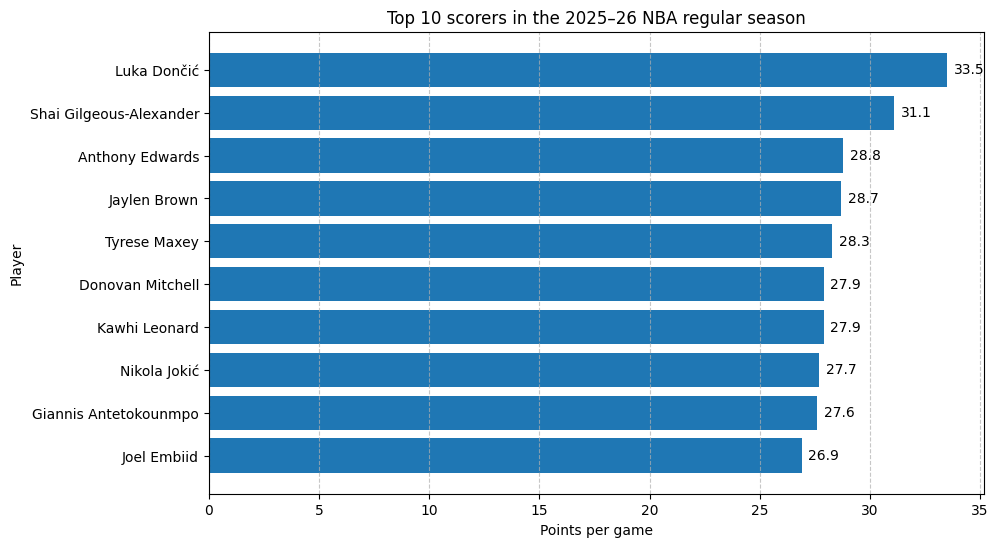

In [23]:
import matplotlib.pyplot as plt

# Create a horizontal bar chart for the top 10 scorers
plt.figure(figsize=(10, 6))
bars = plt.barh(top_scorers["Player"], top_scorers["PTS"])

plt.xlabel("Points per game")
plt.ylabel("Player")
plt.title("Top 10 scorers in the 2025–26 NBA regular season")
plt.gca().invert_yaxis()  # show the highest scorer at the top
plt.grid(axis="x", linestyle="--", alpha=0.7)

# Add PPG values at the end of each bar (for better view)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{width:.1f}", va="center")

plt.show()

## Leaders in basic box score categories

After ranking scorers, I also looked at three other core box score metrics:
- assists (`AST`)
- rebounds (`TRB`)
- blocks (`BLK`)

To keep the notebook readable, I used a small helper function to generate rankings and charts for each category.

In [24]:
import matplotlib.pyplot as plt

def get_top_players(df, stat, n=10):
    top_df = df[["Player", "Team", "Pos", "G", "MP", stat]].sort_values(
        by=stat,
        ascending=False
    ).head(n).reset_index(drop=True)

    top_df.index = top_df.index + 1
    return top_df


def plot_top_players(top_df, stat, x_label, title):
    plt.figure(figsize=(10, 6))
    bars = plt.barh(top_df["Player"], top_df[stat])

    plt.xlabel(x_label)
    plt.ylabel("Player")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.xlim(0, top_df[stat].max() + 2)

    # Add values at the end of each bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width + 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}",
            va="center"
        )

    plt.show()

## Assist leaders

This ranking shows the players with the highest assists per game in the 2025-26 regular season.

In [25]:
top_assists = get_top_players(df_players, "AST")
top_assists

,Player,Team,Pos,G,MP,AST
1,Nikola Jokić,DEN,C,65.0,34.8,10.7
2,Cade Cunningham,DET,PG,64.0,33.9,9.9
3,Josh Giddey,CHI,PG,54.0,32.1,9.1
4,Luka Dončić,LAL,PG,64.0,35.8,8.3
5,Ja Morant,MEM,PG,20.0,28.5,8.1
6,James Harden,2TM,PG,70.0,34.8,8.0
7,Trae Young,2TM,PG,15.0,25.6,8.0
8,Jalen Johnson,ATL,SF,72.0,35.2,7.9
9,Andrew Nembhard,IND,PG,57.0,31.3,7.7
10,Stephon Castle,SAS,PG,68.0,30.0,7.4


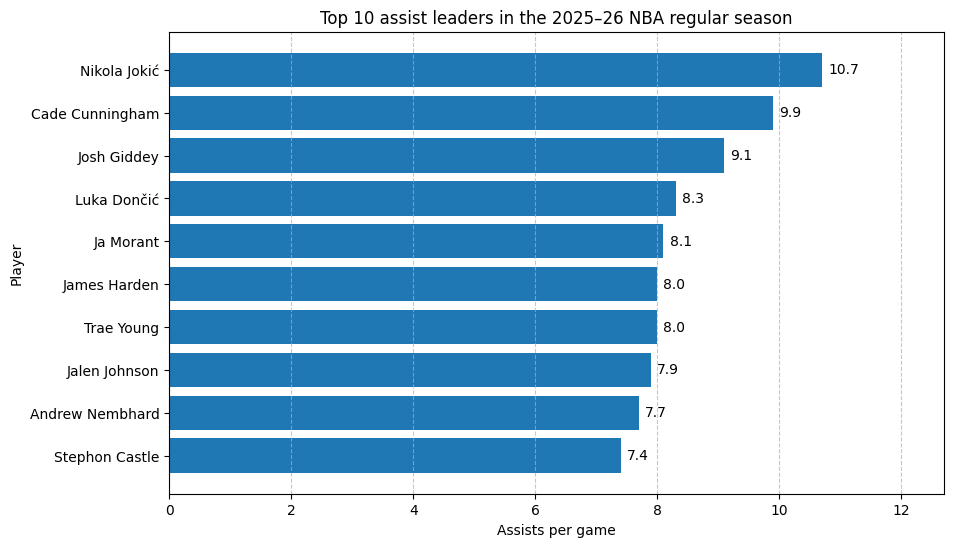

In [26]:
plot_top_players(
    top_assists,
    "AST",
    "Assists per game",
    "Top 10 assist leaders in the 2025–26 NBA regular season"
)

## Rebound leaders

This ranking shows the players with the highest rebounds per game in the 2025-26 regular season.

In [27]:
top_rebounds = get_top_players(df_players, "TRB")
top_rebounds

,Player,Team,Pos,G,MP,TRB
1,Nikola Jokić,DEN,C,65.0,34.8,12.9
2,Karl-Anthony Towns,NYK,C,75.0,31.0,11.9
3,Donovan Clingan,POR,C,77.0,27.2,11.6
4,Victor Wembanyama,SAS,C,64.0,29.2,11.5
5,Rudy Gobert,MIN,C,76.0,31.3,11.5
6,Domantas Sabonis,SAC,C,19.0,29.7,11.4
7,Zach Edey,MEM,C,11.0,25.8,11.1
8,Anthony Davis,DAL,PF,20.0,31.3,11.1
9,Walker Kessler,UTA,C,5.0,30.8,10.8
10,Ivica Zubac,2TM,C,48.0,30.1,10.6


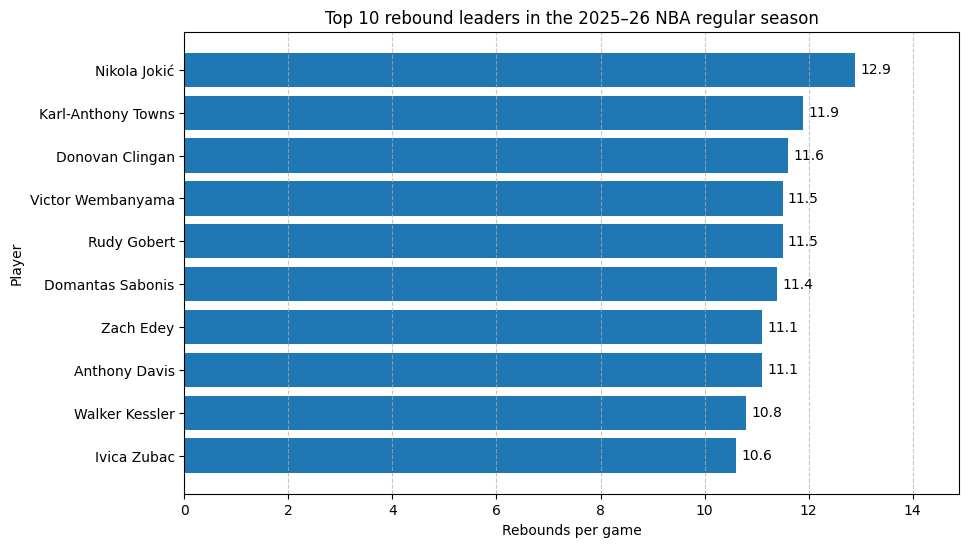

In [28]:
plot_top_players(
    top_rebounds,
    "TRB",
    "Rebounds per game",
    "Top 10 rebound leaders in the 2025–26 NBA regular season"
)

## Block leaders

This ranking shows the players with the highest blocks per game in the 2025-26 regular season.

In [29]:
top_blocks = get_top_players(df_players, "BLK")
top_blocks

,Player,Team,Pos,G,MP,BLK
1,Victor Wembanyama,SAS,C,64.0,29.2,3.1
2,Alex Sarr,WAS,C,48.0,27.2,2.0
3,Zach Edey,MEM,C,11.0,25.8,1.9
4,Jay Huff,IND,C,82.0,21.0,1.9
5,Chet Holmgren,OKC,PF,69.0,28.9,1.9
6,Walker Kessler,UTA,C,5.0,30.8,1.8
7,Anthony Davis,DAL,PF,20.0,31.3,1.7
8,Evan Mobley,CLE,PF,65.0,31.9,1.7
9,Donovan Clingan,POR,C,77.0,27.2,1.7
10,Isaiah Stewart,DET,C,58.0,22.7,1.6


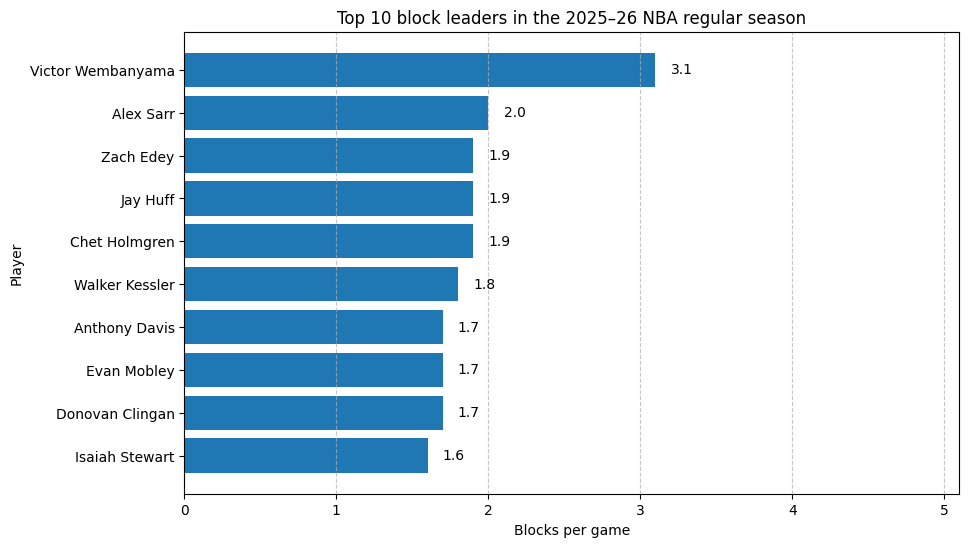

In [30]:
plot_top_players(
    top_blocks,
    "BLK",
    "Blocks per game",
    "Top 10 block leaders in the 2025–26 NBA regular season"
)